In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\apple_feature_engineered.csv")

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [4]:
data = df[['Close']]

In [16]:
train_size = int(len(data) * 0.80)

train = data.iloc[:train_size]

test = data.iloc[train_size:]

In [17]:
history = train['Close'].tolist()

predictions = []

for i in range(len(test)):

    model = ARIMA(history, order=(5,1,0))

    model_fit = model.fit()

    prediction = model_fit.forecast()[0]

    predictions.append(prediction)

    history.append(test['Close'].iloc[i])

In [ ]:
results = pd.DataFrame()
results['Actual'] = test['Close'].values
results['Predicted'] = predictions
results.index = test.index
results.head()

,Actual,Predicted
Date,,
2024-01-03,182.187729,183.752665
2024-01-04,179.873962,182.456928
2024-01-05,179.152115,180.152748
2024-01-08,183.483078,179.082533
2024-01-09,183.067749,183.231911


In [20]:
mae = mean_absolute_error(results['Actual'], results['Predicted'])

In [21]:
rmse = np.sqrt(mean_squared_error(results['Actual'], results['Predicted']))

In [22]:
r2 = r2_score(results['Actual'], results['Predicted'])

In [23]:
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

MAE : 2.14
RMSE : 2.91
R2 Score : 0.98


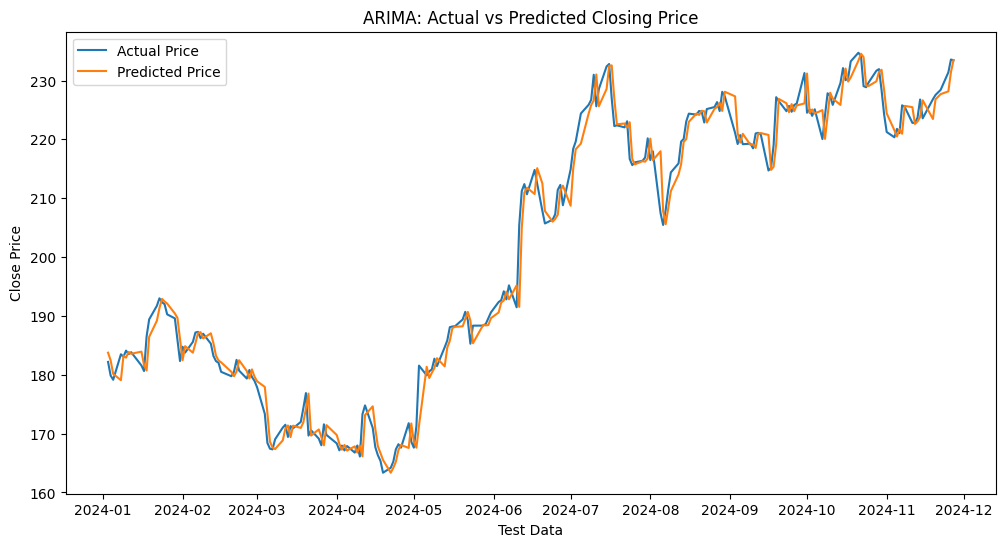

In [24]:
plt.figure(figsize=(12,6))

plt.plot(test.index,
         results['Actual'],
         label='Actual Price')

plt.plot(test.index,
         results['Predicted'],
         label='Predicted Price')

plt.title("ARIMA: Actual vs Predicted Closing Price")

plt.xlabel("Test Data")

plt.ylabel("Close Price")

plt.legend()

plt.show()